# SA

## Imports and files

In [1]:
import os
import pickle
import scipy.io as sio
import itertools

from datetime import datetime
from datetime import timedelta

import numpy as np
import pandas as pd
import geopandas as gpd

import contextily as ctx
from shapely.geometry import Polygon
from shapely.geometry import Point

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from datetime import datetime
from collections import namedtuple

from swmm_api.input_file import read_inp_file, SwmmInput, section_labels as sections
from swmm_api import read_inp_file, read_out_file, swmm5_run

## Functions

In [2]:
def get_poly_rain(x, y, radar_gdf):
    """
    Calculates the rain value of the grid point

    Parameters:
    - x: float or int, the x-coordinate of the point of interest
    - y: float or int, the y-coordinate of the point of interest
    - radar_gdf: GeoDataFrame, a GeoDataFrame object containing radar data with rain values and corresponding geometry information

    Return:
    - poly_rain: float, the average rain value of the four grid points within the square polygon centered around the point of interest

    Notes:
    - The point of interest should be within the extent of the GeoDataFrame object.
    - The function assumes that the GeoDataFrame object has a "rain" column and a "geometry" column containing Point objects.
    """

    # create a Point object from the (x, y) coordinates
    cord1= Point(x, y)

    # use .contains() to identify the row(s) that contain the point of interest
    cord_row1 = radar_gdf["geometry"].contains(cord1)

    # extract the rain value from the corresponding row
    rain_value1 = radar_gdf.loc[cord_row1, "rain"].iloc[0]

    # Calculate the average of 4 grid points
    poly_rain = rain_value1
    return poly_rain

In [3]:
def calculate_rain_data(trans_rain_array, BIAS, radar_basin_legend_gdf, time_vector):
    """
    Calculate rainfall data and basin rain information.

    Parameters:
    - trans_rain_array : numpy.ndarray, the transformed rainfall data.
    - BIAS : float, the bias correction factor.
    - time_vector : list, time vector corresponding to the time steps.

    Returns:
    - radar_poly_grid_gdf : geopandas.GeoDataFrame, GeoDataFrame containing rainfall data for each radar cell.
    - basins_rain_df : pandas.DataFrame, DataFrame containing basin rain information.
    """
    # Define geo parameters
    crs = 'epsg:2039'
    length = 500
    wide = 500
    xll = 185500
    yll = 671500
    cellsize = 500

    # Initialize rain_array_3d
    rain_array_3d = trans_rain_array / (20 * BIAS)
    time_steps = rain_array_3d.shape[-1]

    # Initialize rain_data list and polygons
    rain_data = []
    polygons = []

    # Initialize radar_poly_grid_gdf
    radar_poly_grid_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=crs)

    # Iterate over time steps
    for time in range(time_steps):
        rain_array_2d = rain_array_3d[:, :, time]

        # Create 1D arrays of the X and Y coordinates
        y = np.arange(yll, yll + cellsize * rain_array_2d.shape[0], cellsize)
        x = np.arange(xll, xll + cellsize * rain_array_2d.shape[1], cellsize)

        # Create a 2D grid of X and Y coordinates
        xx, yy = np.meshgrid(x, y)

        # Reshape the arrays into 1D arrays
        x_flat = xx.ravel()
        y_flat = yy.ravel()
        rain_flat = rain_array_2d.flatten()

        # Create a pandas DataFrame with the X and Y coordinates and the rain values
        radar_df = pd.DataFrame({'x': x_flat, 'y': y_flat, 'rain': rain_flat})

        # Create a GeoDataFrame with point geometry
        geometry = gpd.points_from_xy(radar_df.x, radar_df.y)
        radar_gdf = gpd.GeoDataFrame(radar_df, crs=crs, geometry=geometry)

        # Get total bounds of the GeoDataFrame
        xmin, ymin, xmax, ymax = radar_gdf.total_bounds

        # Define the grid Polygon
        cols = list(reversed(np.arange(xmin, xmax + wide, wide)))
        rows = list(reversed(np.arange(ymin, ymax + length, length)))
        rain_l = []

        for y_coord in rows[:-1]:
            for x_coord in cols[:-1]:
                # Get rain data from grid points to polygon
                rain_value = get_poly_rain(x_coord, y_coord, radar_gdf)
                rain_l.append(rain_value)

        rain_data.append({time_vector[time]: rain_l})
        rain_df = pd.DataFrame(rain_data[time])
        radar_poly_grid_gdf = pd.concat([radar_poly_grid_gdf, rain_df], axis=1)

    radar_poly_grid_gdf.index.name = 'radar_cell_num'

    # Sort and re-index radar_basin_legend_gdf
    radar_basin_legend_gdf = radar_basin_legend_gdf.sort_values(by=['Basin_name', 'radar_cell_num']).reset_index(drop=True)

    # Define columns of the final DataFrame
    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[1:])
    basins_rain_df = pd.DataFrame()

    for basin in range(1, len(raanana_basins_gdf) + 1):
        # Create DataFrame with pct, relevant radar cell num, and rain timeseries for each basin
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']] 
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')

        weighted_avgs = []
        for col in basin_rain_columns[1:]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct']) 
            weighted_avgs.append(weighted_avg)

        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns)
        basins_rain_df = pd.concat([basins_rain_df, df_basin])

    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0,inplace=True)
    
    return basins_rain_df


In [4]:
def create_TimeSeriesData_txt(basins_rain_df):
    """
    Update the TimeSeriesData values of SWMM inp file by using basins_rain_df

    Args:
        basins_rain_df (DataFrame): DataFrame where each row represents a basin, and each column represents a timestep. The values are rain (mm) for each basin in a timestep.
    Returns:
        str: Text representation of the updated timeseries data in the specified format.
    """
    # Initialize an empty string to store the text
    
    timeseries_text = ''
    # Write the header
    timeseries_text += ";;Name                 Date          Time         Value     \n"
    timeseries_text += ";;------------ ----------------- ------------- -------------\n"

    # Iterate over each row in the DataFrame
    for index, row in basins_rain_df.iterrows():
        # Get the basin name
        basin_name = int(row['Basin_name'])

        # Write the data to the text
        timestamps = basins_rain_df.columns[1:]  # excluding the first column 'Basin_name'
        values = row.values[1:]  # excluding the first column 'Basin_name'
        dates = [ts.strftime('%m/%d/%Y') for ts in timestamps]  # convert date format
        times = [ts.strftime('%H:%M:%S') for ts in timestamps]  # convert time format
        for i in range(len(timestamps)):
            timeseries_text += f"  {date}_S{basin_name}      {dates[i]}    {times[i]}   {values[i]:.2f}\n"
        timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    return timeseries_text


In [5]:
def BoxCoxTransform(rain_array, lam):
    """
    Apply Box-Cox transformation to rainfall data.
    Parameters:
    -----------
    rain_array : array_like -> Input array containing rainfall data.    
    lam : float -> Lambda parameter for transformation.
    Returns:
    --------
    trans_rain_array : numpy.ndarray -> Transformed rainfall data.    
    bias : float -> Bias factor for normalization.
    """
    
    # change nans values to 0
    rain_array = np.nan_to_num(rain_array, nan=0)
    # Perform Box-Cox transformation
    trans_rain_array = np.where(((rain_array**lam)-1) > 0, (((rain_array**lam)-1)/lam), 0)

    transformation_bias = trans_rain_array.sum() / rain_array.sum()

    # Normalize data to maintain total storm value
    trans_rain_array = trans_rain_array / transformation_bias
    
    return trans_rain_array, transformation_bias


In [6]:
def update_TimeSeriesData(SIM_DIR, date, transform_timeseries_text):
    """
    Update the time series data in an input file used for simulation.
    Args:
    - SIM_DIR (str): Directory where simulation files are located.
    - date (str): Date string used to locate simulation files.
    - transform_timeseries_text (text): text containing transformed time series data.
    Returns:
    - None
    """
    INP_FILE = r"Final.inp"   ## This is the file name before manipulations

    SIM_PATH = os.path.join(SIM_DIR, date + '/')
    inp = read_inp_file(SIM_PATH + INP_FILE)
    timesereies_d = dict(inp[sections.TIMESERIES])
    inp[sections.TIMESERIES] = transform_timeseries_text
    
        ## make sure that time serie data fit number of 'raingauges'
    if len(inp[sections.TIMESERIES].keys()) != len(inp[sections.RAINGAGES].keys()):
        print('ERROR')

    ## Edit the time series name and its corresponding rain gauge field so that they will be the same
    for basin_timeserie in range(len(list(inp[sections.TIMESERIES].keys()))):
    #     print(basin_timeserie)
        basin_timeserie_name = inp[sections.TIMESERIES][list(inp[sections.TIMESERIES].keys())[basin_timeserie]]['name']
        inp[sections.RAINGAGES][list(inp[sections.RAINGAGES].keys())[basin_timeserie]]['timeseries'] = basin_timeserie_name

    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(SIM_PATH + file_name + '.inp')


In [7]:
def load_runoff_obs_to_df(OBS_RUNOFF_DATA_PATH):
    """ Takes OBSERVATION FILE with runoff data and makes pd Dataframe
    :param output_path: str, path name that have the runoff data
    :return: df_obs_runoff
    """
    df_obs_runoff = pd.read_csv (OBS_RUNOFF_DATA_PATH + ".csv")
    df_obs_runoff.dropna(inplace = True) ; df_obs_runoff.rename(columns={'discharge_cms': 'OBS runoff [CMS]'} , inplace=True, errors='raise')
    df_obs_runoff["date_and_time"] =  pd.to_datetime(df_obs_runoff["date_and_time"], format='%d/%m/%Y %H:%M:%S')
    df_obs_runoff = df_obs_runoff.set_index('date_and_time')
    df_obs_runoff.drop(['Unnamed: 0'], axis=1, inplace=True)


    return df_obs_runoff
    
# df_runoff.to_pickle('df_runoff.pkl')

In [8]:
def data_5min_interpolate(df_to_interpolate):
    """ Takes df column and makes 5 min interpolation
    :param df_to_interpolate: pd, df with index datetime64 type
    :return: df_interpol
    """
    df_interpol = df_to_interpolate.resample('5min').mean()
#     df_interpol= df_interpol.interpolate(method='polynomial', order=3)
    df_interpol= df_interpol.interpolate(method='linear')
    return df_interpol

In [9]:
def load_sim_to_df(sim_output_path):
    """ Takes SWMM FILE with runoff data and makes pd Dataframe
    sim_output_path: str, file name that have the swmm runoff data
    return: sim_df
    """
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['outflow', 'rainfall']]
    sim_df.rename(columns={'outflow':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/h]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df

In [10]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model runoff and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the runoff and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_runoff = storm_df['OBS runoff [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_runoff = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_runoff, color='g', label='Observed Runoff')
    ax2 = ax1.twinx()
#     ax2.set_ylabel('Rainfall ($mm/hr$)')

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
#     ax2.set_ylim(ymin=y_rainfall.max() + 50, ymax=0)
    ax2.set_ylim(ymin=70, ymax=0)
    ax1.set_ylim(ymin=0, ymax=90)
    

    sns.lineplot(ax=ax, data=y_sim_runoff, color='r', label='Simulated Runoff')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('Runoff ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18) ; ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()


    return fig


In [11]:
def stat(storm_df):
    """
    Format statistical data from storm_df DataFrame.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
        
    Returns:
        Tuple containing the following:
        
        - swmm_total_runoff (float): Total runoff volume in cubic meters calculated from SWMM data.
        - obs_total_runoff (float): Total runoff volume in cubic meters calculated from OBS data.
        - swmm_max_runoff (float): Runoff peak in CMS (Cubic Meters per Second) from SWMM data.
        - obs_max_runoff (float): Runoff peak in CMS (Cubic Meters per Second) from OBS data.
        - swmm_max_runoff_time (datetime): Time of the runoff peak from SWMM data.
    """
    
    # Total runoff volume [cubic meter]
    swmm_total_runoff = sum(storm_df['SWMM outflow [CMS]'])
    obs_total_runoff = sum(storm_df['OBS runoff [CMS]'])

    # Runoff peak [CMS] and time
    swmm_max_runoff = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_runoff_time = storm_df[storm_df['SWMM outflow [CMS]'] == swmm_max_runoff].index[0]

    obs_max_runoff = storm_df['OBS runoff [CMS]'].max()
    obs_max_runoff_time = storm_df[storm_df['OBS runoff [CMS]'] == obs_max_runoff].index[0]

    return swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff


## Load Data

In [12]:
# Load radar_basin_legend_gdf
directory = r"D:\Development\RESEARCH\Raanana\data\rain_radar\Basin_radar_overlap_pkl"
filename = "radar_basin_legend_gdf.pkl"
filepath = os.path.join(directory, filename)

with open(filepath, "rb") as f:
    radar_basin_legend_gdf = pickle.load(f)


In [13]:
# Load the shapefiles for Raanana
raanana_basins_shapfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_basins_gdf = gpd.read_file(raanana_basins_shapfile)  # sub-basins poly
raanana_basins_gdf.drop(columns=['Shape_Area', 'Area_km2', 'Area_ha','Area_m2'], inplace = True)


# Rain-Radar Transformation
## fromgrided matfile through transform basins rain txt file to inf file timeseries

In [14]:
# Load the storm MAT file
radar_dir = r'D:\Development\RESEARCH\Raanana\data\rain_radar\Row_radar_correct_MAT_files/'

## SELECT the storm event:
filename = '20120113'
rain_gauge_bias = 1.56
radar_data = sio.loadmat(radar_dir + filename)
date = '_'.join([filename[:4], filename[4:6], filename[6:]])

# Rain Data
rain_array_3d= radar_data['event_file'][0][0][0]
# Time Data 
## The Time 1d values 
time_vector= radar_data['event_file'][0][0][1].ravel()
time_vector = pd.to_datetime(time_vector-719529, unit='D').round('1min') # Convert the time from float to datetime and round 


 # Run the simulation

In [15]:
## Find the original Z of the calibrated model
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
sim_dir = os.path.join(sim_dir, date + '/')
INP_FILE = r"Final.inp"


OBS_FILE = date 
obs_runoff_df = data_5min_interpolate(load_runoff_obs_to_df(sim_dir + OBS_FILE))

inp = read_inp_file(sim_dir + INP_FILE) 
file_name = 'find_z'

inp.write_file(sim_dir + file_name + '.inp')

swmm5_run(sim_dir + file_name + '.inp', progress_size=1)
OUT_FILE = file_name +'.out'

sim_df = load_sim_to_df(sim_dir + OUT_FILE)

# Concat observed and simulated data
storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
storm_df[storm_df < 0] = 0
storm_df = storm_df.fillna(0)


# Calculate and store important values
original_total_runoff, obs_total_runoff, original_max_runoff, obs_max_runoff = stat(storm_df)
original_max_rainfall = storm_df['rainfall [mm/h]'].max()

original_total_runoff =  original_total_runoff*60*5   ## from m3/s to m3

print('max rain intense:' , original_max_rainfall)
print('date:' , date)
print('swmm total runoff:' , original_total_runoff)
print('swmm max runoff:' , original_max_runoff)

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2012_01_13/find_z.inp:   0%|       …

max rain intense: 59.754173278808594
date: 2012_01_13
swmm total runoff: 177834.19165501394
swmm max runoff: 32.371585845947266


# LOCAL SA

## Z is max storm rain intensity

lam range is 0.4 to 1.2 represnting about -20% to +20% change in max rain intense value

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2012_01_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2012_01_13/raanana_sensitivity_anal…

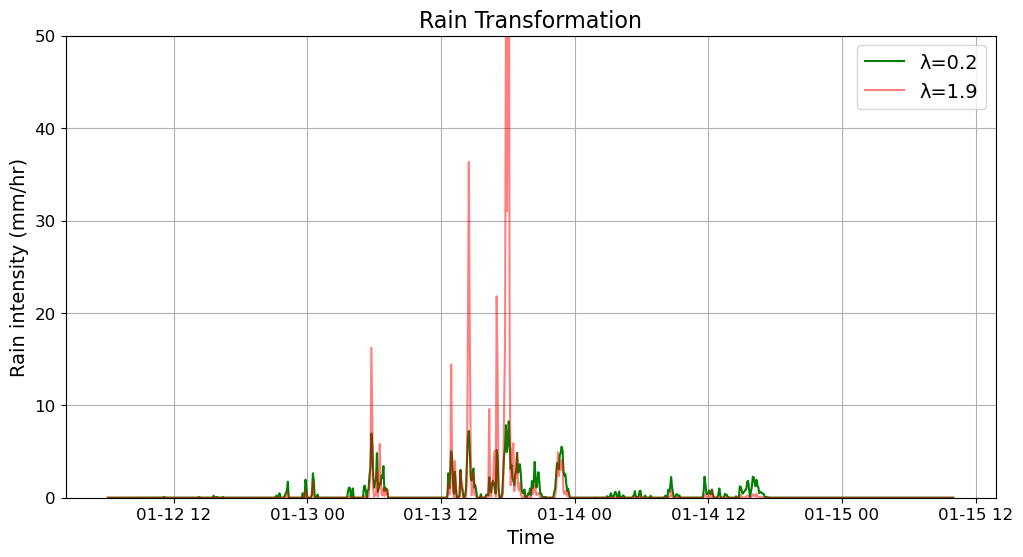

In [16]:
lam_values = np.arange(0.2, 1.4, 0.01)  # Values from 0.4 to 1.2 with 0.05 intervals
# lam_values = np.arange(1, 2, 0.9)
lam_values = [.2,1.95]

max_rain_values = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

for lam in lam_values:
    trans_rain_array, transformation_bias = BoxCoxTransform(rain_array_3d, lam=lam)
    BIAS = rain_gauge_bias

    basins_rain_df = calculate_rain_data(trans_rain_array, BIAS, radar_basin_legend_gdf, time_vector)
    transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)

    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    update_TimeSeriesData(sim_dir, date, transform_timeseries_text)

    sim_dir = os.path.join(sim_dir, date + '/')

    INP_FILE = r"raanana_sensitivity_analysis.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))

    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)

    # Plot the first line in blue
    if lam == lam_values[0]:
        plt.plot(storm_df.index, storm_df['rainfall [mm/h]'], label=f'\u03BB={round(lam, 1)}', color='green')
    # Plot the second line in red
    else:
        plt.plot(storm_df.index, storm_df['rainfall [mm/h]'], label=f'\u03BB={round(lam, 1)}', color='red', alpha=0.5)

    plt.legend(fontsize=14)
    plt.grid(True)
    plt.ylim(0, 150)
    # Title and labels
    plt.title('Rain Transformation', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Rain intensity (mm/hr)', fontsize=14)

    # Increase tick font size
    plt.tick_params(axis='both', which='major', labelsize=12)

    
    
    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)
    max_rain_values.append(storm_df['rainfall [mm/h]'].max())


In [17]:
max_rain_values

[8.276594161987305, 81.83552551269531]

In [18]:
max_rain_values

[13.719078063964844,
 13.811872482299805,
 13.904172897338867,
 14.007627487182617,
 14.088094711303711,
 14.19836139678955,
 14.296028137207031,
 14.403717994689941,
 14.500092506408691,
 14.592119216918945,
 14.694056510925293,
 14.83415412902832,
 14.909000396728516,
 15.002911567687988,
 15.116312980651855,
 15.220672607421875,
 15.336146354675293,
 15.430825233459473,
 15.552236557006836,
 15.657771110534668,
 15.775434494018555,
 15.881214141845703,
 15.987895965576172,
 16.099740982055664,
 16.221921920776367,
 16.331104278564453,
 16.436935424804688,
 16.554672241210938,
 16.685585021972656,
 16.79116439819336,
 16.909624099731445,
 17.024988174438477,
 17.138822555541992,
 17.24875831604004,
 17.371915817260742,
 17.494121551513672,
 17.614748001098633,
 17.73969268798828,
 17.859411239624023,
 17.982688903808594,
 18.10177230834961,
 18.225841522216797,
 18.364097595214844,
 18.48911476135254,
 18.609352111816406,
 18.740808486938477,
 18.86379623413086,
 18.99602508544922,
 

In [19]:
lam_local_sa_df = pd.DataFrame({
    'lam': lam_values,
    'max_rain_values': max_rain_values,
    'swmm_max_runoff_l': swmm_max_runoff_l,
    'swmm_total_runoff_l': swmm_total_runoff_l})

# Calculate percentage change for each parameter
lam_local_sa_df['max_rainfall_change_percent'] = ((lam_local_sa_df['max_rain_values'] / original_max_rainfall) - 1) * 100
lam_local_sa_df['total_runoff_change_percent'] = ((lam_local_sa_df['swmm_total_runoff_l'] / original_total_runoff) - 1) * 100
lam_local_sa_df['max_runoff_change_percent'] = ((lam_local_sa_df['swmm_max_runoff_l'] / original_max_runoff) - 1) * 100


In [20]:
lam_local_sa_df

,lam,max_rain_values,swmm_max_runoff_l,swmm_total_runoff_l,max_rainfall_change_percent,total_runoff_change_percent,max_runoff_change_percent
0,0.30,13.719078,15.675097,83925.005150,-27.229856,-2.990894,-28.824610
1,0.31,13.811872,15.788222,83973.173718,-26.737647,-2.935216,-28.310943
2,0.32,13.904173,15.906363,84047.577463,-26.248057,-2.849213,-27.774508
3,0.33,14.007627,16.026459,84129.778046,-25.699303,-2.754197,-27.229191
4,0.34,14.088095,16.134348,84204.815298,-25.272480,-2.667461,-26.739302
...,...,...,...,...,...,...,...
105,1.35,26.306011,31.058226,90332.561315,39.535048,4.415614,41.025054
106,1.36,26.408331,31.195473,90371.330642,40.077783,4.460428,41.648247
107,1.37,26.517704,31.323843,90366.373244,40.657931,4.454698,42.231134
108,1.38,26.623011,31.444904,90370.161394,41.216509,4.459076,42.780833


In [21]:
lam_local_sa_df

,lam,max_rain_values,swmm_max_runoff_l,swmm_total_runoff_l,max_rainfall_change_percent,total_runoff_change_percent,max_runoff_change_percent
0,0.30,13.719078,15.675097,83925.005150,-27.229856,-2.990894,-28.824610
1,0.31,13.811872,15.788222,83973.173718,-26.737647,-2.935216,-28.310943
2,0.32,13.904173,15.906363,84047.577463,-26.248057,-2.849213,-27.774508
3,0.33,14.007627,16.026459,84129.778046,-25.699303,-2.754197,-27.229191
4,0.34,14.088095,16.134348,84204.815298,-25.272480,-2.667461,-26.739302
...,...,...,...,...,...,...,...
105,1.35,26.306011,31.058226,90332.561315,39.535048,4.415614,41.025054
106,1.36,26.408331,31.195473,90371.330642,40.077783,4.460428,41.648247
107,1.37,26.517704,31.323843,90366.373244,40.657931,4.454698,42.231134
108,1.38,26.623011,31.444904,90370.161394,41.216509,4.459076,42.780833


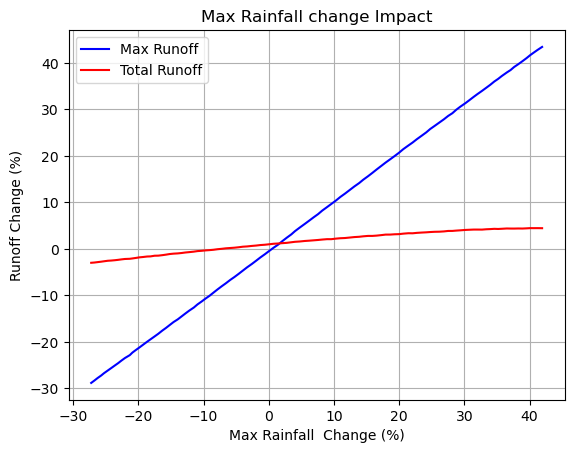

In [22]:
# Plot
plt.plot(lam_local_sa_df['max_rainfall_change_percent'], lam_local_sa_df['max_runoff_change_percent'], label='Max Runoff', color='blue')
plt.plot(lam_local_sa_df['max_rainfall_change_percent'], lam_local_sa_df['total_runoff_change_percent'], label='Total Runoff', color='red')


# Title and labels
plt.title('Max Rainfall change Impact')
plt.xlabel('Max Rainfall  Change (%)')
plt.ylabel('Runoff Change (%)')

# Show plot
plt.legend()
plt.grid(True)
plt.show()


## Z is impervious %

In [18]:
def update_imperviousness_with_factor(subcatchment_dict, factor):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """

    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
#         initial_imperviousness = impervious_initial_values[index]
#         subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict


In [17]:
def update_curve_num_with_factor(infiltration_dict, factor, curve_no_initial_values):
    """
    Update the curve_no values of InfiltrationCurveNumber objects in a dictionary by a factor.

    Args:
        infiltration_dict (dict): A dictionary containing InfiltrationCurveNumber objects as values with subcatchment
                                  names as keys.
        factor (float): The factor by which curve_no values need to be powered.
        curve_no_initial_values (numpy.ndarray): A NumPy array of initial curve_no values corresponding to each subcatchment.

    Returns:
        dict: The updated dictionary with curve_no values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, infiltration_curve) in enumerate(infiltration_dict.items()):
        curve_no = curve_no_initial_values[index]  # Get the initial curve_no value for the current subcatchment
        powered_curve_no = curve_no * factor
        infiltration_curve.curve_no = powered_curve_no

    # Return the updated dictionary
    return infiltration_dict


In [114]:
imp_factors = np.arange(0.1, 1.5, 0.01)  # Values from 0.4 to 1.2 with 0.05 intervals

# imp_factors = np.arange(0.5, 1.51, 0.5)

max_rain_values = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

for imp_factor in imp_factors:
    
    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    sim_dir = os.path.join(sim_dir, date + '/')
    INP_FILE = r"Final.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))
    
    subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
    
    update_imperviousness_with_factor(subcatchment_d, imp_factor)

    
    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)


#     plt.plot(storm_df.index, storm_df['rainfall [mm/h]'], label=f'imp_factor={imp_factor}')
#     plt.legend()
    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)



swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

<Figure size 1200x600 with 0 Axes>

In [25]:
imp_local_sa_df = pd.DataFrame({
    'imp_factors': imp_factors,
    'swmm_max_runoff_l': swmm_max_runoff_l,
    'swmm_total_runoff_l': swmm_total_runoff_l})

# Calculate percentage change for each parameter
imp_local_sa_df['total_runoff_change_percent'] = ((imp_local_sa_df['swmm_total_runoff_l'] / original_total_runoff) - 1) * 100
imp_local_sa_df['max_runoff_change_percent'] = ((imp_local_sa_df['swmm_max_runoff_l'] / original_max_runoff) - 1) * 100


In [26]:
imp_local_sa_df

,imp_factors,swmm_max_runoff_l,swmm_total_runoff_l,total_runoff_change_percent,max_runoff_change_percent
0,0.10,3.034962,8305.775303,-90.399335,-86.219248
1,0.11,3.322663,9178.643269,-89.390385,-84.912894
2,0.12,3.607291,10070.977278,-88.358934,-83.620495
3,0.13,3.888940,10947.116592,-87.346203,-82.341618
4,0.14,4.167739,11843.447417,-86.310132,-81.075684
...,...,...,...,...,...
135,1.45,28.447390,125282.132560,44.813904,29.170117
136,1.46,28.575500,126152.267454,45.819695,29.751826
137,1.47,28.703062,127012.210016,46.813704,30.331041
138,1.48,28.830063,127873.838733,47.809663,30.907709


In [27]:
imp_local_sa_df.iloc[95]

imp_factors                        1.050000
swmm_max_runoff_l                 22.808617
swmm_total_runoff_l            90822.422938
total_runoff_change_percent        4.981847
max_runoff_change_percent          3.566328
Name: 95, dtype: float64

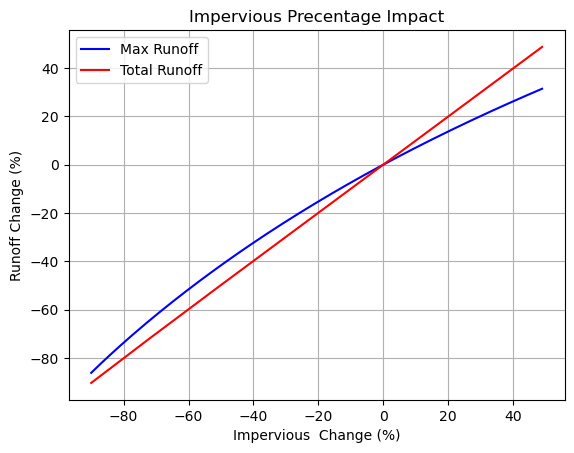

In [28]:
import matplotlib.pyplot as plt

plt.plot((imp_local_sa_df['imp_factors'] - 1) * 100, imp_local_sa_df['max_runoff_change_percent'], label='Max Runoff', color='blue')
plt.plot((imp_local_sa_df['imp_factors'] - 1) * 100, imp_local_sa_df['total_runoff_change_percent'], label='Total Runoff', color='red')

# Title and labels
plt.title('Impervious Precentage Impact')
plt.xlabel('Impervious  Change (%)')
plt.ylabel('Runoff Change (%)')

# Show plot
plt.grid(True)
plt.legend()
plt.show()


## Z is Width


In [39]:
def update_width_with_factor(subcatchment_dict, factor):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with width values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_d.items()):
            width = subcatchment.width
            powered_width = width * factor
            subcatchment.width = powered_width

    # Return the updated dictionary
    return subcatchment_dict

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

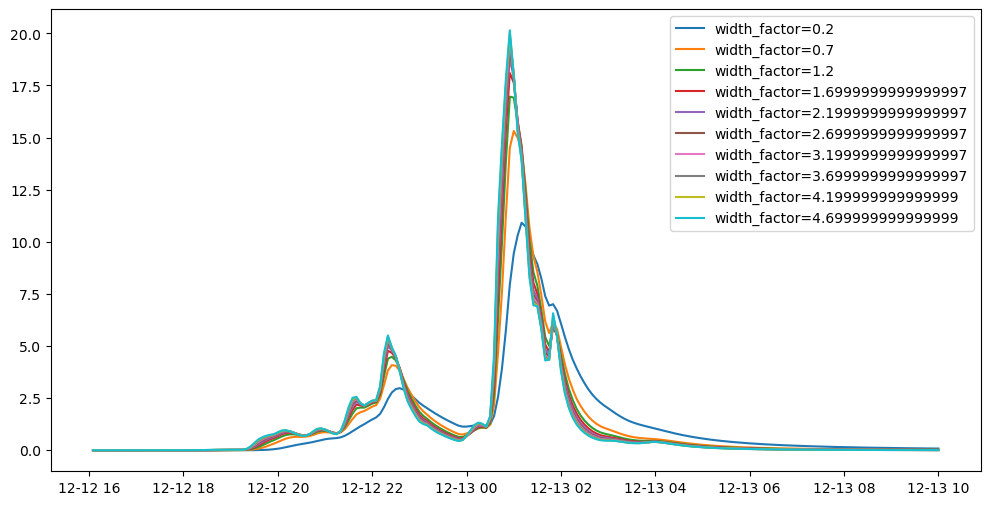

In [40]:
## without! in-subcatchment conduits

width_factors  = np.arange(0.2, 5, 0.5)

max_rain_values = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

for width_factor in width_factors:
    
    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    sim_dir = os.path.join(sim_dir, date + '/')
    INP_FILE = r"Final.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))
    subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
    update_width_with_factor(subcatchment_d, width_factor)
    
    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)


    plt.plot(storm_df.index, storm_df['SWMM outflow [CMS]'], label=f'width_factor={width_factor}')
    plt.legend(); plt.grid()
    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)



# n 

In [64]:
def update_n_with_factor(subareas_dict, factor):
    """
    Update the n_imperv and n_perv values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which n_imperv and n_perv values need to be multiplied.

    Returns:
        dict: The updated dictionary with n_imperv and n_perv values multiplied by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious n values for the current subarea
#         imp_n = subarea.n_imperv
        perv_n = subarea.n_perv
        # Multiply the impervious and pervious n values by the factor
#         updated_imp_n = imp_n * factor
        updated_perv_n = perv_n * factor
        # Update the n values for the current subarea with the multiplied values
#         subarea.n_imperv = updated_imp_n
        subarea.n_perv = updated_perv_n

    # Return the updated dictionary
    return subareas_dict

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

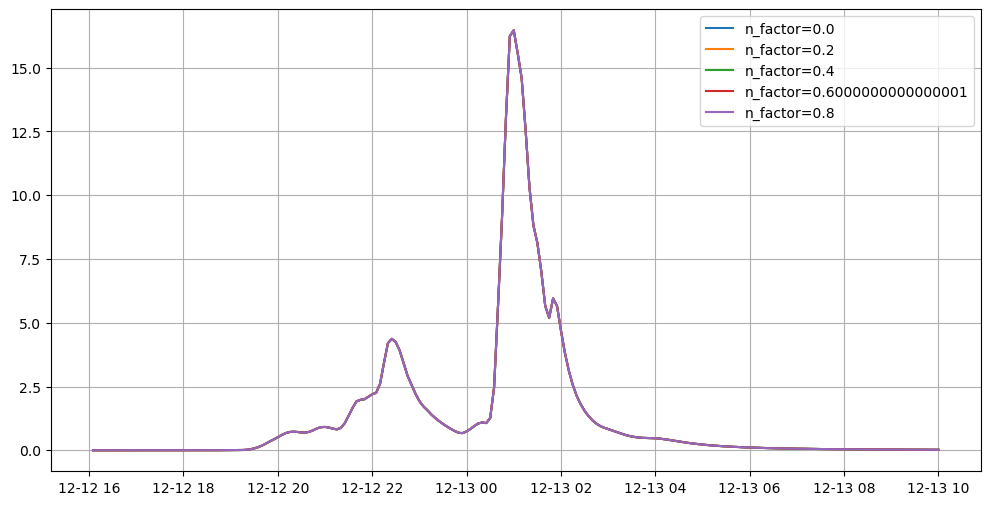

In [65]:
## without! in-subcatchment conduits

n_factors  = np.arange(0, 1, 0.2)

max_rain_values = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

for n_factor in n_factors:
    
    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    sim_dir = os.path.join(sim_dir, date + '/')
    INP_FILE = r"Final.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))
    subareas_d = dict(inp[sections.SUBAREAS])
    update_n_with_factor(subareas_d, n_factor)
    
    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)


    plt.plot(storm_df.index, storm_df['SWMM outflow [CMS]'], label=f'n_factor={n_factor}')
    plt.legend(); plt.grid()
    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)



In [77]:
sim_df = read_out_file(os.path.join(sim_dir, OUT_FILE)).to_frame()['system'][''][['outflow', 'rainfall', 'infiltration']]
sim_df.max()

outflow         16.463505
rainfall        18.852619
infiltration     9.633335
dtype: float64

In [78]:
sim_df = read_out_file(os.path.join(sim_dir, OUT_FILE)).to_frame()['system']
sim_df.max()

  air_temperature          21.111111
  rainfall                 18.852619
  snow_depth                0.000000
  infiltration              9.633335
  runoff                   22.023197
  dry_weather_inflow        0.000000
  groundwater_inflow        0.000000
  RDII_inflow               0.000000
  direct_inflow             0.000000
  lateral_inflow           22.023197
  flooding                  0.000000
  outflow                  16.463505
  volume                13191.142578
  evaporation               0.000000
  PET                       0.000000
dtype: float64

## Z is precent_routed


In [21]:
def update_pct_routed_with_factor(subareas_dict, routed_to, precent):

    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():

        subarea.route_to = routed_to
        subarea.pct_routed = precent

        # Return the updated dictionary
    return subareas_dict

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

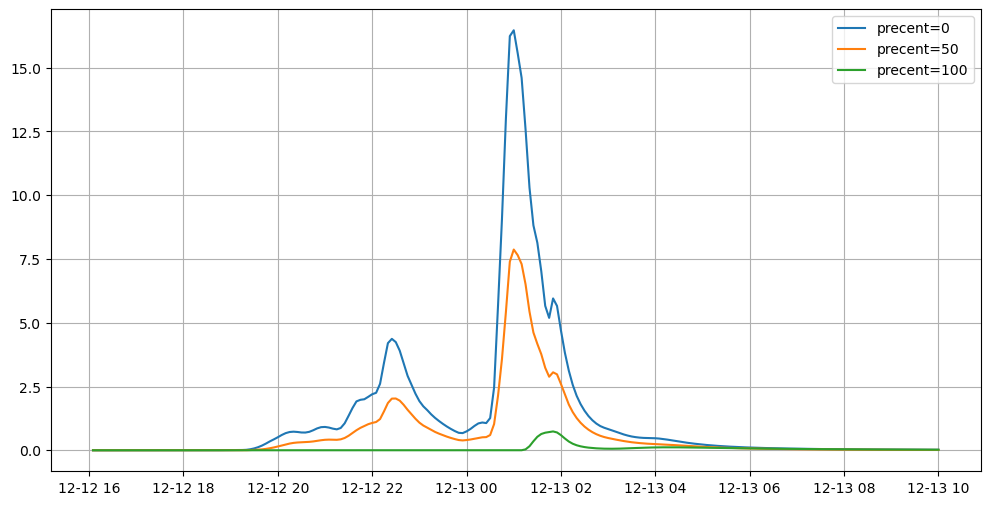

In [23]:
precent_routed_arr = np.arange(0, 101, 50)  # Values from 0.4 to 1.2 with 0.05 intervals
# storage_factors  = np.arange(0.5, 1.51, 0.5)
curve_no_initial_values = np.array([71, 61, 61, 61, 61, 61, 61, 61, 71, 61, 61, 71, 66, 61, 66, 71, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 71])
# curve_no_initial_values = np.array([99, 99, 99, 99,99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99,99, 99, 99,99, 99, 99])

cn_factor=1

max_rain_values = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

routed_to = 'PERVIOUS'
for precent in precent_routed_arr:
    
    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    sim_dir = os.path.join(sim_dir, date + '/')
    INP_FILE = r"Final.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))
    infiltration_d = dict(inp[sections.INFILTRATION])
    subareas_d = dict(inp[sections.SUBAREAS])
    update_pct_routed_with_factor(subareas_d, routed_to, precent)
    update_curve_num_with_factor(infiltration_d, cn_factor, curve_no_initial_values)
    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)


    plt.plot(storm_df.index, storm_df['SWMM outflow [CMS]'], label=f'precent={precent}')
    plt.legend(); plt.grid()
    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)



In [117]:
storm_df

,OBS runoff [CMS],SWMM runoff [CMS],rainfall [mm/h]
2019-12-12 16:05:00,0.0,0.000000,0.0
2019-12-12 16:10:00,0.0,0.000000,0.0
2019-12-12 16:15:00,0.0,0.000000,0.0
2019-12-12 16:20:00,0.0,0.000000,0.0
2019-12-12 16:25:00,0.0,0.000000,0.0
...,...,...,...
2019-12-13 09:40:00,0.0,0.021762,0.0
2019-12-13 09:45:00,0.0,0.021204,0.0
2019-12-13 09:50:00,0.0,0.020665,0.0
2019-12-13 09:55:00,0.0,0.020146,0.0


In [107]:
pct_routed_local_sa_df = pd.DataFrame({
    'storage_factors': precent_routed_arr,
    'swmm_max_runoff_l': swmm_max_runoff_l,
    'swmm_total_runoff_l': swmm_total_runoff_l})

# Calculate percentage change for each parameter
pct_routed_local_sa_df['total_runoff_change_percent'] = ((pct_routed_local_sa_df['swmm_total_runoff_l'] / original_total_runoff) - 1) * 100
pct_routed_local_sa_df['max_runoff_change_percent'] = ((pct_routed_local_sa_df['swmm_max_runoff_l'] / original_max_runoff) - 1) * 100


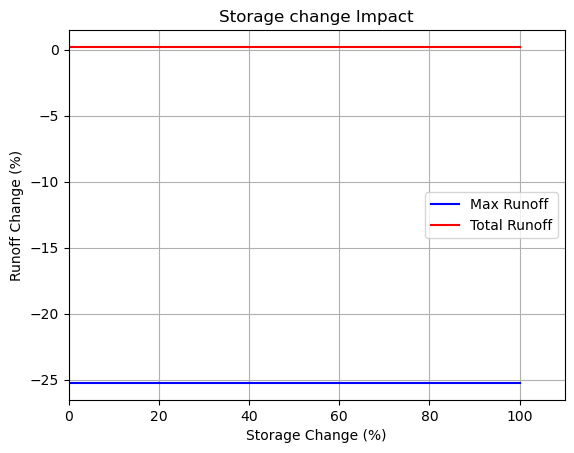

In [108]:
# Plot
plt.plot(pct_routed_local_sa_df['storage_factors'], pct_routed_local_sa_df['max_runoff_change_percent'], label='Max Runoff', color='blue')
plt.plot(pct_routed_local_sa_df['storage_factors'], pct_routed_local_sa_df['total_runoff_change_percent'], label='Total Runoff', color='red')


# Title and labels
plt.title('Storage change Impact')
plt.xlabel('Storage Change (%)')
plt.ylabel('Runoff Change (%)')

# Show plot
plt.legend()
plt.grid(True)
plt.xlim(-0,110)
plt.show()


## Z is Depreesion storage

In [19]:
def update_storage_with_factor(subareas_dict, factor):
    """
    Update the storage values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which storage values need to be powered.

    Returns:
        dict: The updated dictionary with storage values powered by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious storage values for the current subarea
        imp_storage = subarea.storage_imperv
        perv_storage = subarea.storage_perv
        # Multiply the impervious and pervious storage values by the factor
        powered_imp_storage = imp_storage * factor
        powered_perv_storage = perv_storage * factor
        # Update the storage values for the current subarea with the powered values
        subarea.storage_imperv = powered_imp_storage
        subarea.storage_perv = powered_perv_storage

    # Return the updated dictionary
    return subareas_dict

In [30]:
storage_factors = np.arange(0.1, 20, 0.05)  # Values from 0.4 to 1.2 with 0.05 intervals
# storage_factors  = np.arange(0.5, 1.51, 0.5)

max_rain_values = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

for storage_factor in storage_factors:
    
    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    sim_dir = os.path.join(sim_dir, date + '/')
    INP_FILE = r"Final.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))
    
    subareas_d = dict(inp[sections.SUBAREAS])
    update_storage_with_factor(subareas_d, storage_factor)
    
    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)


#     plt.plot(storm_df.index, storm_df['rainfall [mm/h]'], label=f'imp_factor={imp_factor}')
#     plt.legend()
    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)



swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

<Figure size 1200x600 with 0 Axes>

In [31]:
storage_local_sa_df = pd.DataFrame({
    'storage_factors': storage_factors,
    'swmm_max_runoff_l': swmm_max_runoff_l,
    'swmm_total_runoff_l': swmm_total_runoff_l})

# Calculate percentage change for each parameter
storage_local_sa_df['total_runoff_change_percent'] = ((storage_local_sa_df['swmm_total_runoff_l'] / original_total_runoff) - 1) * 100
storage_local_sa_df['max_runoff_change_percent'] = ((storage_local_sa_df['swmm_max_runoff_l'] / original_max_runoff) - 1) * 100


In [32]:
storage_local_sa_df

,storage_factors,swmm_max_runoff_l,swmm_total_runoff_l,total_runoff_change_percent,max_runoff_change_percent
0,0.10,22.749411,101417.620004,17.228859,3.297493
1,0.15,22.749407,100595.653207,16.278746,3.297476
2,0.20,22.749405,99760.352523,15.313220,3.297467
3,0.25,22.749388,98936.702783,14.361161,3.297389
4,0.30,22.749361,98109.510083,13.405007,3.297268
...,...,...,...,...,...
393,19.75,14.984340,66919.765466,-22.647290,-31.961106
394,19.80,14.984340,66919.765466,-22.647290,-31.961106
395,19.85,14.984340,66919.765466,-22.647290,-31.961106
396,19.90,14.984340,66919.765466,-22.647290,-31.961106


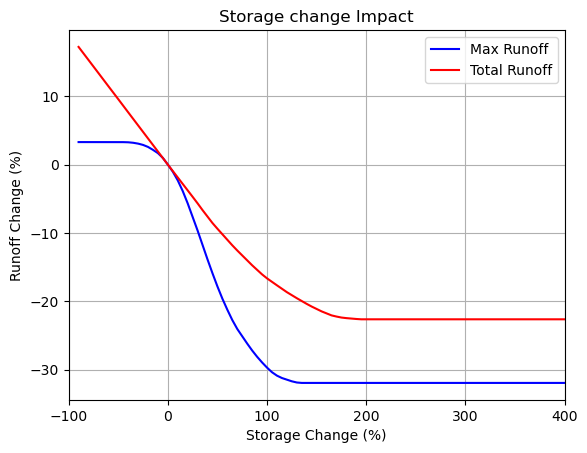

In [33]:
# Plot
plt.plot((storage_local_sa_df['storage_factors']-1)*100, storage_local_sa_df['max_runoff_change_percent'], label='Max Runoff', color='blue')
plt.plot((storage_local_sa_df['storage_factors']-1)*100, storage_local_sa_df['total_runoff_change_percent'], label='Total Runoff', color='red')


# Title and labels
plt.title('Storage change Impact')
plt.xlabel('Storage Change (%)')
plt.ylabel('Runoff Change (%)')

# Show plot
plt.legend()
plt.grid(True)
plt.xlim(-100,400)
plt.show()


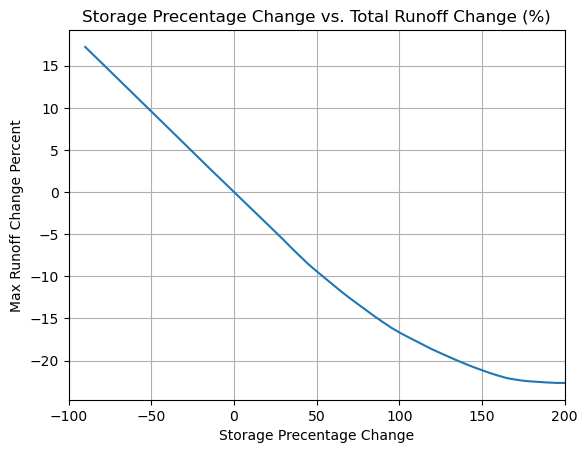

In [34]:
import matplotlib.pyplot as plt


# Plot
plt.plot((storage_local_sa_df['storage_factors']-1)*100, storage_local_sa_df['total_runoff_change_percent'])

# Title and labels
plt.title('Storage Precentage Change vs. Total Runoff Change (%)')
plt.xlabel('Storage Precentage Change')
plt.ylabel('Max Runoff Change Percent')
plt.xlim(-100,200)
# Show plot
plt.grid(True)
plt.show()


# GLOBAL SA

In [34]:
lam_factors = np.arange(0.2, 1.7, 0.2)  # Values from 0.4 to 1.2 with 0.05 intervals
imp_factors = np.arange(0.1, 1.41, 0.2)

storage_factors_1 = np.arange(0.1, 1, 0.9)
storage_factors_2 = np.arange(1, 14, 6)

# Concatenate arrays to get the final storage_factors array
storage_factors = np.concatenate([storage_factors_1, storage_factors_2])




FACTOR_COMBINATION = np.array(list(itertools.product(lam_factors, imp_factors, storage_factors)))
len(FACTOR_COMBINATION)

224

In [35]:

lam_factors_l = []
imp_factor_l = []
storage_factor_l = []
max_rain_values_l = []
swmm_total_runoff_l = []
swmm_max_runoff_l = []

plt.figure(figsize=(12, 6))

for lam_factor, imp_factor, storage_factor in FACTOR_COMBINATION:
    trans_rain_array, transformation_bias = BoxCoxTransform(rain_array_3d, lam=lam_factor)
    BIAS = rain_gauge_bias

    basins_rain_df = calculate_rain_data(trans_rain_array, BIAS, radar_basin_legend_gdf, time_vector)
    transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)

    sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
    update_TimeSeriesData(sim_dir, date, transform_timeseries_text)
    sim_dir = os.path.join(sim_dir, date + '/')

    INP_FILE = r"raanana_sensitivity_analysis.inp"
    inp = read_inp_file(os.path.join(sim_dir, INP_FILE))

    
    subareas_d = dict(inp[sections.SUBAREAS])
    subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
    
    update_imperviousness_with_factor(subcatchment_d, imp_factor)
    update_storage_with_factor(subareas_d, storage_factor)
    
        
    
    file_name = 'raanana_sensitivity_analysis'
    inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
    swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
    OUT_FILE = file_name + '.out'

    sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)

#     plt.plot(storm_df.index, storm_df['rainfall [mm/h]'], label=f'lam={lam}')

    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff = stat(storm_df)
    swmm_total_runoff_l.append(swmm_total_runoff*60*5)    ## fix it
    swmm_max_runoff_l.append(swmm_max_runoff)
    max_rain_values_l.append(storm_df['rainfall [mm/h]'].max())
    
    lam_factors_l.append(lam_factor)
    imp_factor_l.append(imp_factor)
    storage_factor_l.append(storage_factor)


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2019_12_13/raanana_sensitivity_anal…

<Figure size 1200x600 with 0 Axes>

In [26]:
# # Define RMSD function
# def calculate_rmsd(sim_values, original_values):
#     squared_diff = (sim_values - original_values) ** 2
#     rmsd = np.sqrt(np.mean(squared_diff))
#     return rmsd

# # Define Bias calculation function
# def calculate_bias(sim_values, original_values):
#     bias = np.mean(sim_values - original_values)
#     return bias

# # Define Bias calculation function
# def calculate_percent_bias(sim_values, original_values):
#     percent_bias = np.sum(sim_values - original_values) / np.sum(original_values) * 100
#     return percent_bias

# max_runoff_rmsd_values = [calculate_rmsd(sim_max_runoff, original_max_runoff) for sim_max_runoff in swmm_max_runoff_l]
# total_runoff_rmsd_values = [calculate_rmsd(sim_total_runoff, original_total_runoff) for sim_total_runoff in swmm_total_runoff_l]

# max_runoff_bias_values = [calculate_bias(sim_max_runoff, original_max_runoff) for sim_max_runoff in swmm_max_runoff_l]
# total_runoff_bias_values = [calculate_bias(sim_total_runoff, original_total_runoff) for sim_total_runoff in swmm_total_runoff_l]


# # Calculate percent bias values for max runoff and total runoff
# max_runoff_percent_bias_values = [calculate_percent_bias(sim_max_runoff, original_max_runoff) for sim_max_runoff in swmm_max_runoff_l]
# total_runoff_percent_bias_values = [calculate_percent_bias(sim_total_runoff, original_total_runoff) for sim_total_runoff in swmm_total_runoff_l]

# # Now you can use these percent bias values to plot your contours
# # Modify your plotting code accordingly



In [41]:

# Create DataFrame
global_sa_df = pd.DataFrame({
    'lam_factor': lam_factors_l,
    'imp_change': [(x - 1) * 100 for x in imp_factor_l],
    'storage_change': [(x - 1) * 100 for x in storage_factor_l],
    'max_rain_val': max_rain_values_l,
    'swmm_max_runoff': swmm_max_runoff_l,
    'swmm_total_runoff': swmm_total_runoff_l,
})


# Calculate percentage change for each parameter
global_sa_df['max_rainfall_change'] = ((global_sa_df['max_rain_val'] / original_max_rainfall) - 1) * 100
global_sa_df['max_runoff_change_percent'] = ((global_sa_df['swmm_max_runoff'] / original_max_runoff) - 1) * 100
global_sa_df['total_runoff_change_percent'] = ((global_sa_df['swmm_total_runoff'] / original_total_runoff) - 1) * 100

# Reorder columns
global_sa_df = global_sa_df[['max_rainfall_change', 'imp_change', 'storage_change', 'total_runoff_change_percent',
                              'swmm_total_runoff','swmm_max_runoff']]


In [85]:
cons_factors_df

,max_rainfall_change,imp_change,storage_change,total_runoff_change_percent,swmm_total_runoff,swmm_max_runoff
84,2.763703,-90.0,-90.0,-88.032662,11474.218263,1.787439
85,2.763703,-90.0,0.0,-89.783612,9795.416470,1.729398
86,2.763703,-90.0,600.0,-92.745296,6955.769983,0.947185
87,2.763703,-90.0,1200.0,-92.745296,6955.769983,0.947185
88,2.763703,-70.0,-90.0,-63.904071,34608.578811,6.665271
89,2.763703,-70.0,0.0,-69.260347,29473.010530,6.475946
90,2.763703,-70.0,600.0,-78.039738,21055.378296,3.583909
91,2.763703,-70.0,1200.0,-78.039738,21055.378296,3.583909
92,2.763703,-50.0,-90.0,-39.935415,57589.594213,11.584743
93,2.763703,-50.0,0.0,-48.920765,48974.489707,11.250796


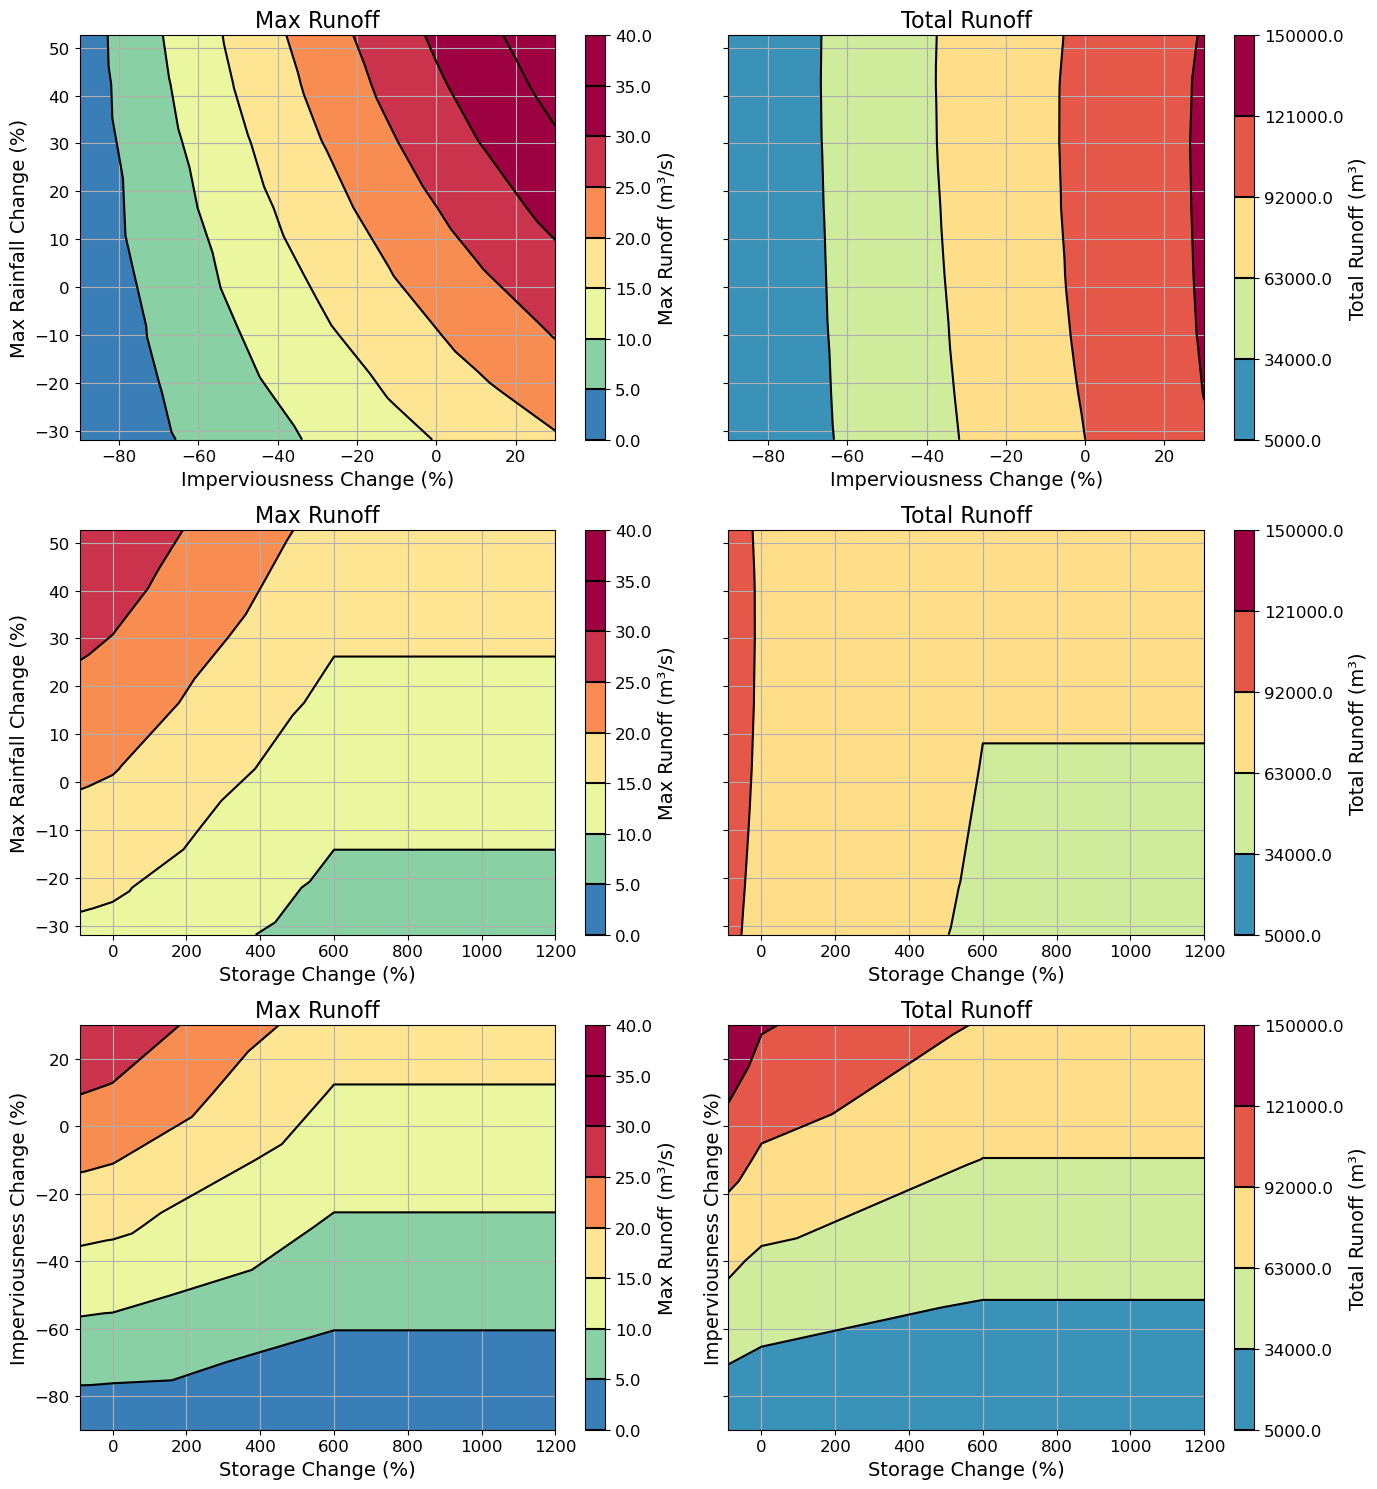

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Define your levels
max_runoff_levels = np.linspace(0, 40, 9)  # Example levels for max runoff
total_runoff_levels = np.linspace(5000, 150000, 6)  # Example levels for total runoff

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 15), sharey='row')

cons_factors_df = global_sa_df[(global_sa_df['storage_change'] >= -3) & (global_sa_df['storage_change'] <= 3)]

# Axis
imp_change_const = cons_factors_df['imp_change']
max_rainfall_change_const = cons_factors_df['max_rainfall_change']
# Contour
max_runoff_const = cons_factors_df['swmm_max_runoff']
total_runoff_const = cons_factors_df['swmm_total_runoff']
# Plot for imp_change and max_rainfall_change (Max Runoff Bias)
contour1 = axs[0, 0].tricontourf(imp_change_const, max_rainfall_change_const, max_runoff_const, cmap='Spectral_r', levels=max_runoff_levels, vmin=0, vmax=30)
contour_lines1 = axs[0, 0].tricontour(imp_change_const, max_rainfall_change_const, max_runoff_const, colors='k', levels=max_runoff_levels)
cbar1 = fig.colorbar(contour1, ax=axs[0, 0])
cbar1.ax.tick_params(labelsize=12)  # Adjust colorbar font size
cbar1.set_label('Max Runoff (m³/s)', fontsize=14)
cbar1.add_lines(contour_lines1)
cbar1.ax.set_yticklabels([str(round(level, 2)) for level in max_runoff_levels])
axs[0, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 0].set_title('Max Runoff', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=12)
axs[0, 0].grid(True)
# Plot for imp_change and max_rainfall_change (Total Runoff Bias)
contour2 = axs[0, 1].tricontourf(imp_change_const, max_rainfall_change_const, total_runoff_const, cmap='Spectral_r', levels=total_runoff_levels, vmin=5000, vmax=125000)
contour_lines2 = axs[0, 1].tricontour(imp_change_const, max_rainfall_change_const, total_runoff_const, colors='k', levels=total_runoff_levels)
cbar2 = fig.colorbar(contour2, ax=axs[0, 1])
cbar2.ax.tick_params(labelsize=12)  # Adjust colorbar font size
cbar2.set_label('Total Runoff (m³)', fontsize=14)
cbar2.add_lines(contour_lines2)
cbar2.ax.set_yticklabels([str(round(level, 2)) for level in total_runoff_levels])
axs[0, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 1].set_title('Total Runoff', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=12)
axs[0, 1].grid(True)

# Filter the DataFrame based on the constant value of imp_change
cons_factors_df = global_sa_df[(global_sa_df['imp_change'] >= -10) & (global_sa_df['imp_change'] <= 10)]

# Extract data for plotting
# Axis
storage_change_const = cons_factors_df['storage_change']
max_rainfall_change_const = cons_factors_df['max_rainfall_change']
# Contour
max_runoff_const = cons_factors_df['swmm_max_runoff']
total_runoff_const = cons_factors_df['swmm_total_runoff']

# Plot for storage_change and max_rainfall_change (Max Runoff Bias)
contour3 = axs[1, 0].tricontourf(storage_change_const, max_rainfall_change_const, max_runoff_const, cmap='Spectral_r', levels=max_runoff_levels, vmin=0, vmax=30)
contour_lines3 = axs[1, 0].tricontour(storage_change_const, max_rainfall_change_const, max_runoff_const, colors='k', levels=max_runoff_levels)
cbar3 = fig.colorbar(contour3, ax=axs[1, 0])
cbar3.ax.tick_params(labelsize=12)  # Adjust colorbar font size
cbar3.set_label('Max Runoff (m³/s)', fontsize=14)
cbar3.add_lines(contour_lines3)
cbar3.ax.set_yticklabels([str(round(level, 2)) for level in max_runoff_levels])
axs[1, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 0].set_title('Max Runoff', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=12)
axs[1, 0].grid(True)

# Plot for storage_change and max_rainfall_change (Total Runoff Bias)
contour4 = axs[1, 1].tricontourf(storage_change_const, max_rainfall_change_const, total_runoff_const, cmap='Spectral_r', levels=total_runoff_levels, vmin=5000, vmax=125000)
contour_lines4 = axs[1, 1].tricontour(storage_change_const, max_rainfall_change_const, total_runoff_const, colors='k', levels=total_runoff_levels)
cbar4 = fig.colorbar(contour4, ax=axs[1, 1])
cbar4.ax.tick_params(labelsize=12)  # Adjust colorbar font size
cbar4.set_label('Total Runoff (m³)', fontsize=14)
cbar4.add_lines(contour_lines4)
cbar4.ax.set_yticklabels([str(round(level, 2)) for level in total_runoff_levels])
axs[1, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 1].set_title('Total Runoff', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=12)
axs[1, 1].grid(True)

# Filter the DataFrame based on the constant value of max_rainfall_change
cons_factors_df = global_sa_df[(global_sa_df['max_rainfall_change'] >= -10) & (global_sa_df['max_rainfall_change'] <= 10)]

# Extract data for plotting
# Axis
storage_change_const = cons_factors_df['storage_change']
imp_change_const = cons_factors_df['imp_change']
# Contour
max_runoff_const = cons_factors_df['swmm_max_runoff']
total_runoff_const = cons_factors_df['swmm_total_runoff']

# Plot for imp_change and storage_change (Max Runoff Bias)
contour5 = axs[2, 0].tricontourf(storage_change_const, imp_change_const, max_runoff_const, cmap='Spectral_r', levels=max_runoff_levels, vmin=0, vmax=30)
contour_lines5 = axs[2, 0].tricontour(storage_change_const, imp_change_const, max_runoff_const, colors='k', levels=max_runoff_levels)
cbar5 = fig.colorbar(contour5, ax=axs[2, 0])
cbar5.ax.tick_params(labelsize=12)  # Adjust colorbar font size
cbar5.set_label('Max Runoff (m³/s)', fontsize=14)
cbar5.add_lines(contour_lines5)
cbar5.ax.set_yticklabels([str(round(level, 2)) for level in max_runoff_levels])
axs[2, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[2, 0].set_ylabel('Imperviousness Change (%)', fontsize=14)
axs[2, 0].set_title('Max Runoff', fontsize=16)
axs[2, 0].tick_params(axis='both', which='major', labelsize=12)
axs[2, 0].grid(True)

# Plot for imp_change and storage_change (Total Runoff Bias)
contour6 = axs[2, 1].tricontourf(storage_change_const, imp_change_const, total_runoff_const, cmap='Spectral_r', levels=total_runoff_levels, vmin=5000, vmax=125000)
contour_lines6 = axs[2, 1].tricontour(storage_change_const, imp_change_const, total_runoff_const, colors='k', levels=total_runoff_levels)
cbar6 = fig.colorbar(contour6, ax=axs[2, 1])
cbar6.ax.tick_params(labelsize=12)  # Adjust colorbar font size
cbar6.set_label('Total Runoff (m³)', fontsize=14)
cbar6.add_lines(contour_lines6)
cbar6.ax.set_yticklabels([str(round(level, 2)) for level in total_runoff_levels])
axs[2, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[2, 1].set_ylabel('Imperviousness Change (%)', fontsize=14)
axs[2, 1].set_title('Total Runoff', fontsize=16)
axs[2, 1].tick_params(axis='both', which='major', labelsize=12)
axs[2, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [80]:
storage_change_const

Series([], Name: storage_change, dtype: float64)

C:\Users\raznu\AppData\Local\Temp\ipykernel_1512\1874826507.py:21: UserWarning: No contour levels were found within the data range.
  contour_lines1 = axs[0, 0].tricontour(imp_change_const, max_rainfall_change_const, max_runoff_percent_bias_const, colors='k', levels=levels)
C:\Users\raznu\AppData\Local\Temp\ipykernel_1512\1874826507.py:32: UserWarning: No contour levels were found within the data range.
  contour_lines2 = axs[0, 1].tricontour(imp_change_const, max_rainfall_change_const, total_runoff_percent_bias_const, colors='k', levels=levels)


ValueError: x and y arrays must have a length of at least 3

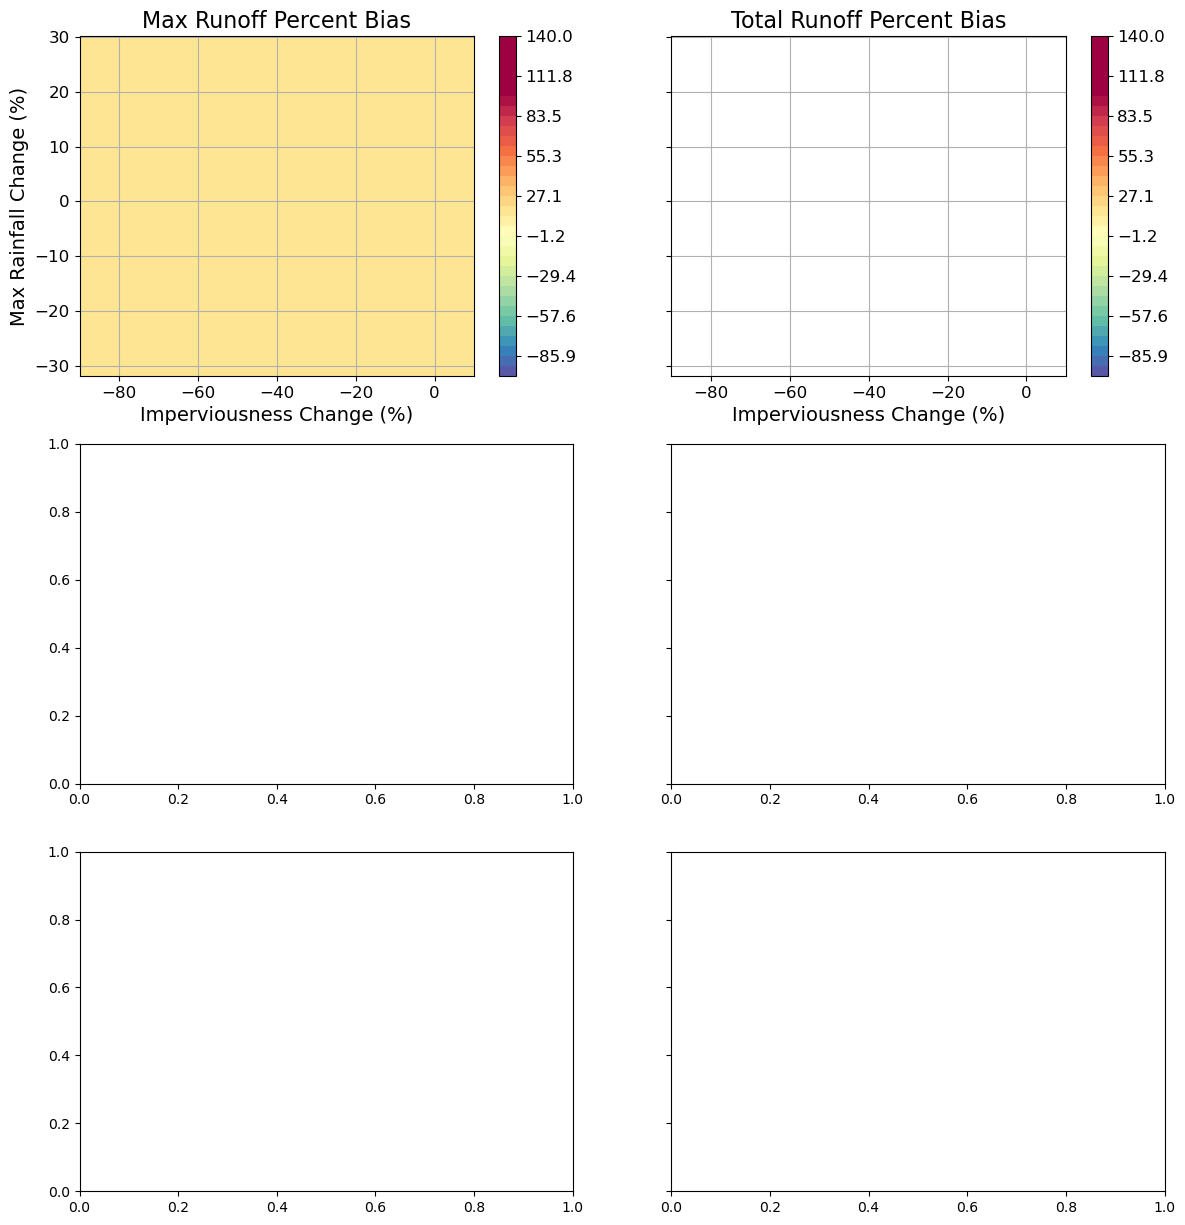

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Filter the DataFrame based on the constant value of storage_change
cons_factors_df = global_sa_df[(global_sa_df['storage_change'] >= -3) & (global_sa_df['storage_change'] <= 3)]

# Extract data for plotting
imp_change_const = cons_factors_df['imp_change']
max_rainfall_change_const = cons_factors_df['max_rainfall_change']
max_runoff_percent_bias_const = cons_factors_df['swmm_max_runoff']
total_runoff_percent_bias_const = cons_factors_df['swmm_total_runoff']

# Determine levels for contour lines
# levels = np.linspace(-100, 140, num=35)

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 15), sharey='row')

# Plot for imp_change and max_rainfall_change (Max Runoff Bias)
contour1 = axs[0, 0].tricontourf(imp_change_const, max_rainfall_change_const, max_runoff_percent_bias_const, cmap='Spectral_r', levels=levels, vmin=-100, vmax=100)
contour_lines1 = axs[0, 0].tricontour(imp_change_const, max_rainfall_change_const, max_runoff_percent_bias_const, colors='k', levels=levels)
cbar1 = fig.colorbar(contour1, ax=axs[0, 0])
cbar1.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[0, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 0].set_title('Max Runoff Percent Bias', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=12)
axs[0, 0].grid(True)

# Plot for imp_change and max_rainfall_change (Total Runoff Bias)
contour2 = axs[0, 1].tricontourf(imp_change_const, max_rainfall_change_const, total_runoff_percent_bias_const, cmap='Spectral_r', levels=levels, vmin=-100, vmax=100)
contour_lines2 = axs[0, 1].tricontour(imp_change_const, max_rainfall_change_const, total_runoff_percent_bias_const, colors='k', levels=levels)
cbar2 = fig.colorbar(contour2, ax=axs[0, 1])
cbar2.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[0, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 1].set_title('Total Runoff Percent Bias', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=12)
axs[0, 1].grid(True)

# Filter the DataFrame based on the constant value of imp_change
cons_factors_df = global_sa_df[(global_sa_df['imp_change'] >= -3) & (global_sa_df['imp_change'] <= 3)]

# Extract data for plotting
storage_change_const = cons_factors_df['storage_change']
max_rainfall_change_const = cons_factors_df['max_rainfall_change']
max_runoff_percent_bias_const = cons_factors_df['max_runoff_percent_bias']
total_runoff_percent_bias_const = cons_factors_df['total_runoff_percent_bias']

# Plot for storage_change and max_rainfall_change (Max Runoff Bias)
contour3 = axs[1, 0].tricontourf(storage_change_const, max_rainfall_change_const, max_runoff_percent_bias_const, cmap='Spectral_r', levels=levels, vmin=-100, vmax=100)
contour_lines3 = axs[1, 0].tricontour(storage_change_const, max_rainfall_change_const, max_runoff_percent_bias_const, colors='k', levels=levels)
cbar3 = fig.colorbar(contour3, ax=axs[1, 0])
cbar3.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[1, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 0].set_title('Max Runoff Percent Bias', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=12)
axs[1, 0].grid(True)

# Plot for storage_change and max_rainfall_change (Total Runoff Bias)
contour4 = axs[1, 1].tricontourf(storage_change_const, max_rainfall_change_const, total_runoff_percent_bias_const, cmap='Spectral_r', levels=levels, vmin=-100, vmax=100)
contour_lines4 = axs[1, 1].tricontour(storage_change_const, max_rainfall_change_const, total_runoff_percent_bias_const, colors='k', levels=levels)
cbar4 = fig.colorbar(contour4, ax=axs[1, 1])
cbar4.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[1, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 1].set_title('Total Runoff Percent Bias', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=12)
axs[1, 1].grid(True)

# Filter the DataFrame based on the constant value of max_rainfall_change
cons_factors_df = global_sa_df[(global_sa_df['max_rainfall_change'] >= -5) & (global_sa_df['max_rainfall_change'] <= 5)]
cons_factors_df
# Extract data for plotting
storage_change_const = cons_factors_df['storage_change']
imp_change_const = cons_factors_df['imp_change']
max_runoff_percent_bias_const = cons_factors_df['max_runoff_percent_bias']
total_runoff_percent_bias_const = cons_factors_df['total_runoff_percent_bias']

# Plot for imp_change and storage_change (Max Runoff Bias)
contour5 = axs[2, 0].tricontourf(storage_change_const, imp_change_const, max_runoff_percent_bias_const, cmap='Spectral_r', levels=levels, vmin=-100, vmax=100)
contour_lines5 = axs[2, 0].tricontour(storage_change_const, imp_change_const, max_runoff_percent_bias_const, colors='k', levels=levels)
cbar5 = fig.colorbar(contour5, ax=axs[2, 0])
cbar5.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[2, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[2, 0].set_ylabel('Imperviousness Change (%)', fontsize=14)
axs[2, 0].set_title('Max Runoff Percent Bias', fontsize=16)
axs[2, 0].tick_params(axis='both', which='major', labelsize=12)
axs[2, 0].grid(True)

# Plot for imp_change and storage_change (Total Runoff Bias)
contour6 = axs[2, 1].tricontourf(storage_change_const, imp_change_const, total_runoff_percent_bias_const, cmap='Spectral_r', levels=levels, vmin=-100, vmax=100)
contour_lines6 = axs[2, 1].tricontour(storage_change_const, imp_change_const, total_runoff_percent_bias_const, colors='k', levels=levels)
cbar6 = fig.colorbar(contour6, ax=axs[2, 1])
cbar6.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[2, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[2, 1].set_ylabel('Imperviousness Change (%)', fontsize=14)
axs[2, 1].set_title('Total Runoff Percent Bias', fontsize=16)
axs[2, 1].tick_params(axis='both', which='major', labelsize=12)
axs[2, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [41]:
cons_factors_df = global_sa_df[(global_sa_df['max_rainfall_change'] >= -5) & (global_sa_df['max_rainfall_change'] <= 5)]
cons_factors_df

,max_rainfall_change,imp_change,storage_change,total_runoff_change_percent,max_runoff_change_percent,max_runoff_rmsd,total_runoff_rmsd,max_runoff_bias,total_runoff_bias,max_runoff_percent_bias,total_runoff_percent_bias
560,-3.982719,-90.0,-90.0,-88.413451,-86.956084,19.150510,76488.689511,-19.150510,-76488.689511,-86.956084,-88.413451
561,-3.982719,-90.0,0.0,-90.175221,-87.047900,19.170731,78012.840369,-19.170731,-78012.840369,-87.047900,-90.175221
562,-3.982719,-90.0,200.0,-92.528851,-91.451885,20.140629,80049.024551,-20.140629,-80049.024551,-91.451885,-92.528851
563,-3.982719,-90.0,400.0,-92.528851,-91.451885,20.140629,80049.024551,-20.140629,-80049.024551,-91.451885,-92.528851
564,-3.982719,-90.0,600.0,-92.528851,-91.451885,20.140629,80049.024551,-20.140629,-80049.024551,-91.451885,-92.528851
...,...,...,...,...,...,...,...,...,...,...,...
779,2.763703,40.0,400.0,9.307651,-11.172149,2.460464,8052.281493,-2.460464,8052.281493,-11.172149,9.307651
780,2.763703,40.0,600.0,9.307651,-11.172149,2.460464,8052.281493,-2.460464,8052.281493,-11.172149,9.307651
781,2.763703,40.0,800.0,9.307651,-11.172149,2.460464,8052.281493,-2.460464,8052.281493,-11.172149,9.307651
782,2.763703,40.0,1000.0,9.307651,-11.172149,2.460464,8052.281493,-2.460464,8052.281493,-11.172149,9.307651


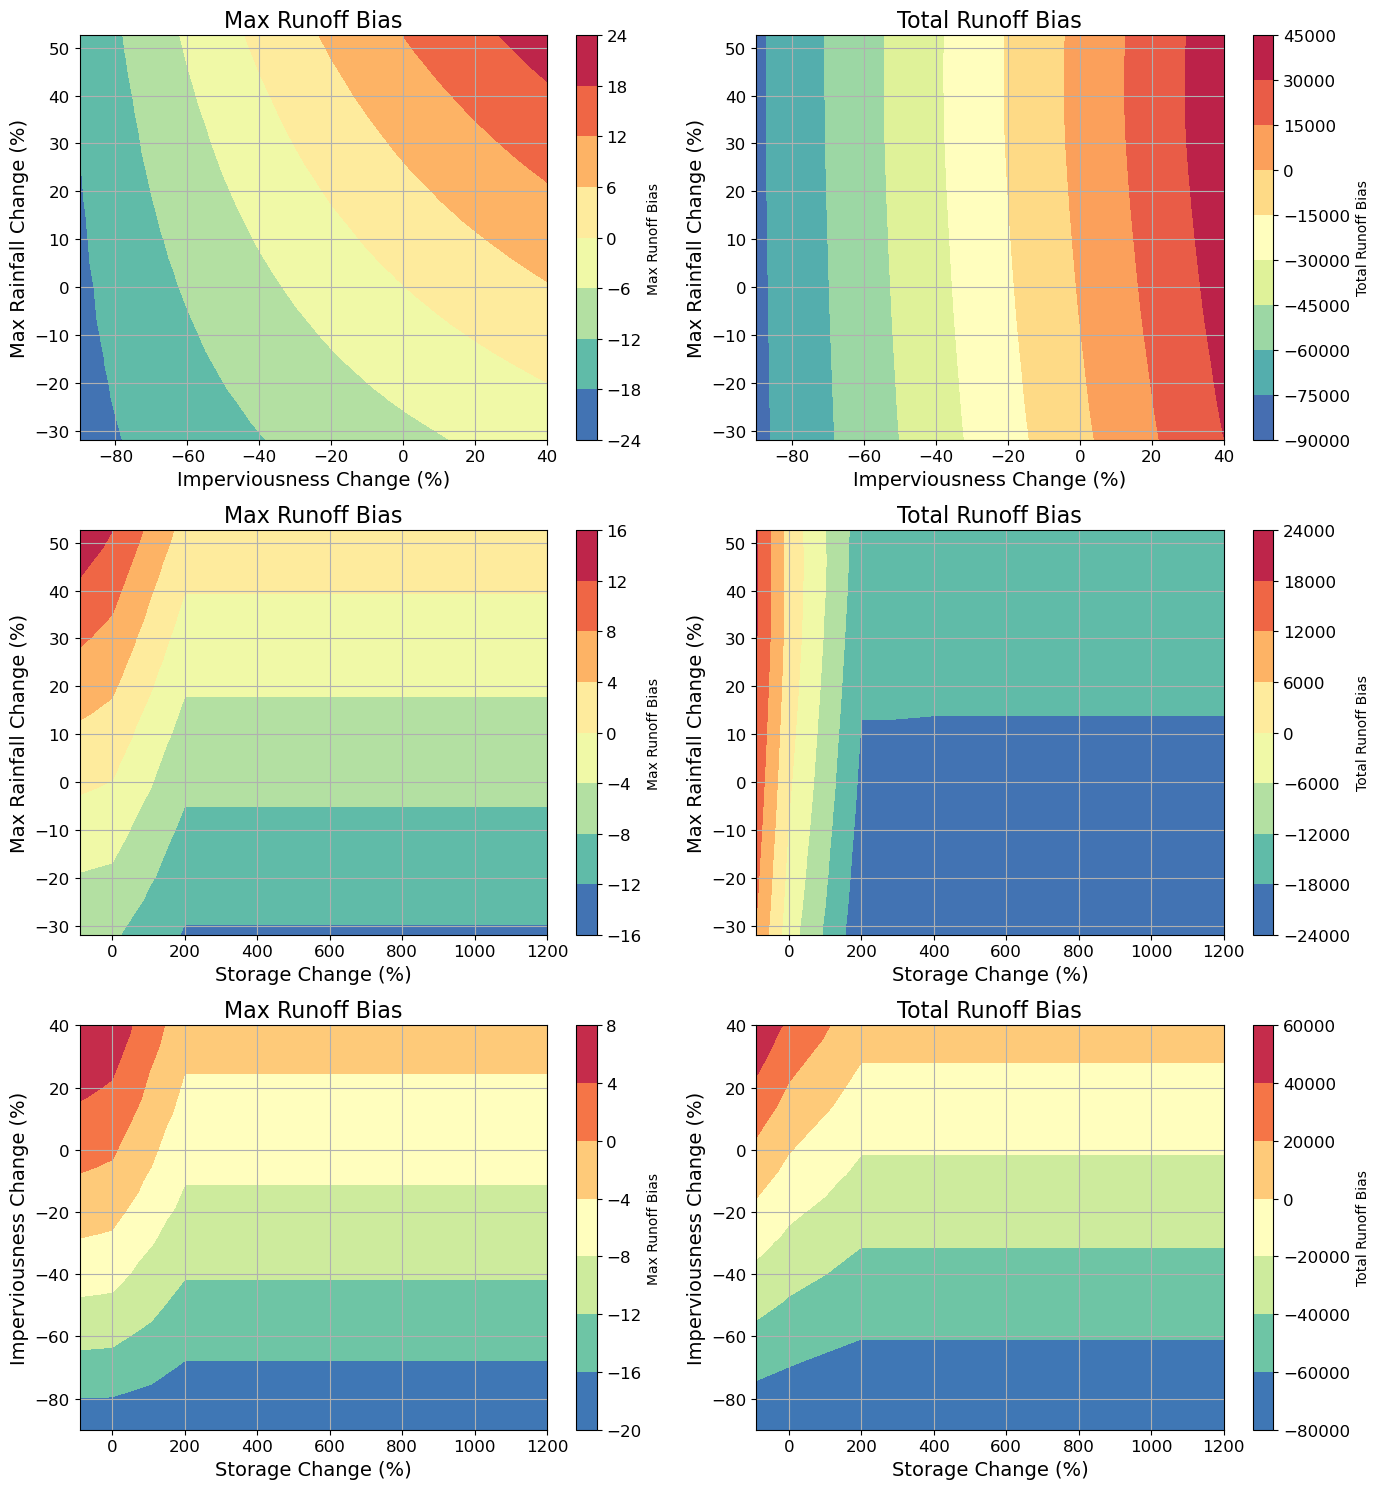

In [42]:
import matplotlib.pyplot as plt

# Filter the DataFrame based on the constant value of storage_change
cons_factors_df = global_sa_df[(global_sa_df['storage_change'] >= -3) & (global_sa_df['storage_change'] <= 3)]

# Extract data for plotting
imp_change_const = cons_factors_df['imp_change']
max_rainfall_change_const = cons_factors_df['max_rainfall_change']
max_runoff_bias_const = cons_factors_df['max_runoff_bias']
total_runoff_bias_const = cons_factors_df['total_runoff_bias']

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# Plot for imp_change and max_rainfall_change (Max Runoff Bias)
contour1 = axs[0, 0].tricontourf(imp_change_const, max_rainfall_change_const, max_runoff_bias_const, cmap='Spectral_r')
cbar1 = fig.colorbar(contour1, ax=axs[0, 0], label='Max Runoff Bias')
cbar1.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[0, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 0].set_title('Max Runoff Bias', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=12)
axs[0, 0].grid(True)

# Plot for imp_change and max_rainfall_change (Total Runoff Bias)
contour2 = axs[0, 1].tricontourf(imp_change_const, max_rainfall_change_const, total_runoff_bias_const, cmap='Spectral_r')
cbar2 = fig.colorbar(contour2, ax=axs[0, 1], label='Total Runoff Bias')
cbar2.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[0, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 1].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 1].set_title('Total Runoff Bias', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=12)
axs[0, 1].grid(True)

# Filter the DataFrame based on the constant value of imp_change
cons_factors_df = global_sa_df[(global_sa_df['imp_change'] >= -3) & (global_sa_df['imp_change'] <= 3)]

# Extract data for plotting
storage_change_const = cons_factors_df['storage_change']
max_rainfall_change_const = cons_factors_df['max_rainfall_change']
max_runoff_bias_const = cons_factors_df['max_runoff_bias']
total_runoff_bias_const = cons_factors_df['total_runoff_bias']

# Plot for storage_change and max_rainfall_change (Max Runoff Bias)
contour3 = axs[1, 0].tricontourf(storage_change_const, max_rainfall_change_const, max_runoff_bias_const, cmap='Spectral_r')
cbar3 = fig.colorbar(contour3, ax=axs[1, 0], label='Max Runoff Bias')
cbar3.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[1, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 0].set_title('Max Runoff Bias', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=12)
axs[1, 0].grid(True)

# Plot for storage_change and max_rainfall_change (Total Runoff Bias)
contour4 = axs[1, 1].tricontourf(storage_change_const, max_rainfall_change_const, total_runoff_bias_const, cmap='Spectral_r')
cbar4 = fig.colorbar(contour4, ax=axs[1, 1], label='Total Runoff Bias')
cbar4.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[1, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 1].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 1].set_title('Total Runoff Bias', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=12)
axs[1, 1].grid(True)

# Filter the DataFrame based on the constant value of max_rainfall_change
cons_factors_df = global_sa_df[(global_sa_df['max_rainfall_change'] >= -3) & (global_sa_df['max_rainfall_change'] <= 3)]

# Extract data for plotting
storage_change_const = cons_factors_df['storage_change']
imp_change_const = cons_factors_df['imp_change']
max_runoff_bias_const = cons_factors_df['max_runoff_bias']
total_runoff_bias_const = cons_factors_df['total_runoff_bias']

# Plot for imp_change and storage_change (Max Runoff Bias)
contour5 = axs[2, 0].tricontourf(storage_change_const, imp_change_const, max_runoff_bias_const, cmap='Spectral_r')
cbar5 = fig.colorbar(contour5, ax=axs[2, 0], label='Max Runoff Bias')
cbar5.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[2, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[2, 0].set_ylabel('Imperviousness Change (%)', fontsize=14)
axs[2, 0].set_title('Max Runoff Bias', fontsize=16)
axs[2, 0].tick_params(axis='both', which='major', labelsize=12)
axs[2, 0].grid(True)

# Plot for imp_change and storage_change (Total Runoff Bias)
contour6 = axs[2, 1].tricontourf(storage_change_const, imp_change_const, total_runoff_bias_const, cmap='Spectral_r')
cbar6 = fig.colorbar(contour6, ax=axs[2, 1], label='Total Runoff Bias')
cbar6.ax.tick_params(labelsize=12)  # Adjust colorbar font size
axs[2, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[2, 1].set_ylabel('Imperviousness Change (%)', fontsize=14)
axs[2, 1].set_title('Total Runoff Bias', fontsize=16)
axs[2, 1].tick_params(axis='both', which='major', labelsize=12)
axs[2, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [43]:
מה עוד לעשות?
1. להוסיף סופה
2. לצופך איזוברים (גם הרצה יותר צפופה וגם איזוברים צפופים)


SyntaxError: invalid syntax (2447003576.py, line 2)

In [ ]:
מה עוד לעשות

In [ ]:
import matplotlib.pyplot as plt

# Filter out NaN values from max_runoff_rmsd and total_runoff_rmsd
filtered_df = global_sa_df.dropna(subset=['max_runoff_rmsd', 'total_runoff_rmsd'])

# Extract data for plotting
imp_change = filtered_df['imp_change']
storage_change = filtered_df['storage_change']
max_rainfall_change = filtered_df['max_rainfall_change']

max_runoff_rmsd = filtered_df['max_runoff_rmsd']
total_runoff_rmsd = filtered_df['total_runoff_rmsd']

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# Plot for imp_change and max_rainfall_change (Max Runoff RMSD)
contour1 = axs[0, 0].tricontourf(imp_change, max_rainfall_change, max_runoff_rmsd, cmap='viridis')
fig.colorbar(contour1, ax=axs[0, 0], label='Max Runoff RMSD')
axs[0, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 0].set_title('Max Runoff RMSD', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=12)
axs[0, 0].grid(True)

# Plot for imp_change and max_rainfall_change (Total Runoff RMSD)
contour2 = axs[0, 1].tricontourf(imp_change, max_rainfall_change, total_runoff_rmsd, cmap='viridis')
fig.colorbar(contour2, ax=axs[0, 1], label='Total Runoff RMSD')
axs[0, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 1].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 1].set_title('Total Runoff RMSD', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=12)
axs[0, 1].grid(True)

# Plot for storage_change and max_rainfall_change (Max Runoff RMSD)
contour3 = axs[1, 0].tricontourf(storage_change, max_rainfall_change, max_runoff_rmsd, cmap='viridis')
fig.colorbar(contour3, ax=axs[1, 0], label='Max Runoff RMSD')
axs[1, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 0].set_title('Max Runoff RMSD', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=12)
axs[1, 0].grid(True)

# Plot for storage_change and max_rainfall_change (Total Runoff RMSD)
contour4 = axs[1, 1].tricontourf(storage_change, max_rainfall_change, total_runoff_rmsd, cmap='viridis')
fig.colorbar(contour4, ax=axs[1, 1], label='Total Runoff RMSD')
axs[1, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 1].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 1].set_title('Total Runoff RMSD', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=12)
axs[1, 1].grid(True)

# Plot for imp_change and storage_change (Max Runoff RMSD)
contour5 = axs[2, 0].tricontourf(imp_change, storage_change, max_runoff_rmsd, cmap='viridis')
fig.colorbar(contour5, ax=axs[2, 0], label='Max Runoff RMSD')
axs[2, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[2, 0].set_ylabel('Storage Change (%)', fontsize=14)
axs[2, 0].set_title('Max Runoff RMSD', fontsize=16)
axs[2, 0].tick_params(axis='both', which='major', labelsize=12)
axs[2, 0].grid(True)

# Plot for imp_change and storage_change (Total Runoff RMSD)
contour6 = axs[2, 1].tricontourf(imp_change, storage_change, total_runoff_rmsd, cmap='viridis')
fig.colorbar(contour6, ax=axs[2, 1], label='Total Runoff RMSD')
axs[2, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[2, 1].set_ylabel('Storage Change (%)', fontsize=14)
axs[2, 1].set_title('Total Runoff RMSD', fontsize=16)
axs[2, 1].tick_params(axis='both', which='major', labelsize=12)
axs[2, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
global_sa_df['imp_change'] 

In [ ]:
rows_with_zero_imp_change = global_sa_df[global_sa_df['imp_change'] == 0]
rows_with_zero_imp_change

In [ ]:
# Filter out NaN values from max_runoff_rmsd and total_runoff_rmsd
filtered_df = global_sa_df.dropna(subset=['max_runoff_rmsd', 'total_runoff_rmsd'])

# Extract data for plotting
imp_change = filtered_df['imp_change']
storage_change = filtered_df['storage_change']
max_rainfall_change = filtered_df['max_rainfall_change']

max_runoff_bias = filtered_df['max_runoff_bias']
total_runoff_bias = filtered_df['total_runoff_bias']

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# Plot for imp_change and max_rainfall_change (Max Runoff Bias)
contour1 = axs[0, 0].tricontourf(imp_change, max_rainfall_change, max_runoff_bias, cmap='viridis')
fig.colorbar(contour1, ax=axs[0, 0], label='Max Runoff Bias')
axs[0, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 0].set_title('Max Runoff Bias', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=12)
axs[0, 0].grid(True)

# Plot for imp_change and max_rainfall_change (Total Runoff Bias)
contour2 = axs[0, 1].tricontourf(imp_change, max_rainfall_change, total_runoff_bias, cmap='viridis')
fig.colorbar(contour2, ax=axs[0, 1], label='Total Runoff Bias')
axs[0, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[0, 1].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[0, 1].set_title('Total Runoff Bias', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=12)
axs[0, 1].grid(True)

# Plot for storage_change and max_rainfall_change (Max Runoff Bias)
contour3 = axs[1, 0].tricontourf(storage_change, max_rainfall_change, max_runoff_bias, cmap='viridis')
fig.colorbar(contour3, ax=axs[1, 0], label='Max Runoff Bias')
axs[1, 0].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 0].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 0].set_title('Max Runoff Bias', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=12)
axs[1, 0].grid(True)

# Plot for storage_change and max_rainfall_change (Total Runoff Bias)
contour4 = axs[1, 1].tricontourf(storage_change, max_rainfall_change, total_runoff_bias, cmap='viridis')
fig.colorbar(contour4, ax=axs[1, 1], label='Total Runoff Bias')
axs[1, 1].set_xlabel('Storage Change (%)', fontsize=14)
axs[1, 1].set_ylabel('Max Rainfall Change (%)', fontsize=14)
axs[1, 1].set_title('Total Runoff Bias', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=12)
axs[1, 1].grid(True)

# Plot for imp_change and storage_change (Max Runoff Bias)
contour5 = axs[2, 0].tricontourf(imp_change, storage_change, max_runoff_bias, cmap='viridis')
fig.colorbar(contour5, ax=axs[2, 0], label='Max Runoff Bias')
axs[2, 0].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[2, 0].set_ylabel('Storage Change (%)', fontsize=14)
axs[2, 0].set_title('Max Runoff Bias', fontsize=16)
axs[2, 0].tick_params(axis='both', which='major', labelsize=12)
axs[2, 0].grid(True)

# Plot for imp_change and storage_change (Total Runoff Bias)
contour6 = axs[2, 1].tricontourf(imp_change, storage_change, total_runoff_bias, cmap='viridis')
fig.colorbar(contour6, ax=axs[2, 1], label='Total Runoff Bias')
axs[2, 1].set_xlabel('Imperviousness Change (%)', fontsize=14)
axs[2, 1].set_ylabel('Storage Change (%)', fontsize=14)
axs[2, 1].set_title('Total Runoff Bias', fontsize=16)
axs[2, 1].tick_params(axis='both', which='major', labelsize=12)
axs[2, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
# # Transformation 
# lam = 1
# trans_rain_array, transformation_bias = BoxCoxTransform(rain_array_3d,lam = lam)

# BIAS = rain_gauge_bias

# basins_rain_df = calculate_rain_data(trans_rain_array, BIAS, radar_basin_legend_gdf, time_vector)
# transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)
# # print(timeseries_text)
# sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
# update_TimeSeriesData(sim_dir, date, transform_timeseries_text)

In [ ]:
read_out_file(sim_dir+OUT_FILE).to_frame()['system']['']

In [ ]:

    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['runoff', 'rainfall']]
    sim_df.rename(columns={'runoff':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/h]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df

In [ ]:
# Transformation 
lam = 1.5
trans_rain_array, transformation_bias = BoxCoxTransform(rain_array_3d,lam = lam)

BIAS = rain_gauge_bias

basins_rain_df = calculate_rain_data(trans_rain_array, BIAS, radar_basin_legend_gdf, time_vector)
transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)
# print(timeseries_text)
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
update_TimeSeriesData(sim_dir, date, transform_timeseries_text)


# file_name = 'raanana_sensitivity_analysis'                      

sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
sim_dir = os.path.join(sim_dir, date + '/')

OBS_FILE = date 
obs_runoff_df = data_5min_interpolate(load_runoff_obs_to_df(sim_dir + OBS_FILE))

INP_FILE = r"raanana_sensitivity_analysis.inp"
inp = read_inp_file(sim_dir + INP_FILE) 

file_name = 'micheck'
inp.write_file(sim_dir + file_name + '.inp')
swmm5_run(sim_dir + file_name + '.inp', progress_size=1)
OUT_FILE = file_name +'.out'

sim_df = load_sim_to_df(sim_dir+OUT_FILE)

# concat observed and simulated data -> The storm_df (choose one of 2 options)
storm_df = pd.concat( [obs_runoff_df , sim_df] , axis=1)   ## concat by the larger index
#                         storm_df = obs_runoff_df.join(sim_df, how='right')           ## join by the smaller index
storm_df[storm_df < 0] = 0  ; storm_df = storm_df.fillna(0)

fig = observation_and_swmm_hydrograph(storm_df,date)
